# Test 2: Quadruple-Well Baseline Comparison

This notebook uses the same restored quadruple-well target, initialization, DMPS, and KSWGD computations, then adds baseline samplers for comparison.

In [1]:
from dataclasses import replace
from pathlib import Path
import time
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir
setup_plot_style(scale=1.5)
np.random.seed(42)

from systems import (
    QuadrupleWellConfig, FourWellPotential,
    generate_quadruple_langevin_trajectory,
    init_quadruple_particles_uniform_outside,
)
from dmps import fit_diffusion_map_dmps_2d, run_diffusion_map_dmps_2d
from kswgd import train_sdmd_solver, sdmd_kernel_spectrum_2d, run_kernel_spectrum_transport_2d
from baseline import (
    mmd_rbf, sliced_wasserstein, particle_well_coverage,
    compute_kl_divergence_kde,
)
from experiment_plots import (
    plot_quad_pair_snapshots, plot_quad_heatmaps, plot_quad_movement_rate,
    plot_quad_well_density_evolution, plot_quad_kl_divergence,
)

cfg = replace(
    QuadrupleWellConfig(),
    n_target=10000, n_particles=3000, n_iter=3000,
    step_size=0.05, dt=0.01, substeps=10, burnin=1000, seed=42,
)
potential = FourWellPotential(cfg.temperature, a=cfg.a, b=cfg.b, coupling=cfg.coupling)
WELL_CENTERS = FourWellPotential.centers
WELL_RADIUS = 0.4
ALPHA_REPULSIVE = 0.5
DM_SPECTRAL_MODES = 1000
RECORD_INTERVAL = 100
SNAPSHOT_STEPS = [0, 1000, 3000]
WELL_DENSITY_STEPS = [0, 100, 300, 500, 1000, 1500, 2000, 2500, 3000]
KL_STEPS = list(range(0, cfg.n_iter + 1, 100))
ALL_SNAPSHOT_STEPS = sorted(set(SNAPSHOT_STEPS + WELL_DENSITY_STEPS + KL_STEPS))
ensure_dir('figures/quadruple_well')
print(cfg)
print(f'alpha_repulsive={ALPHA_REPULSIVE}, well_radius={WELL_RADIUS}, DM spectral modes={DM_SPECTRAL_MODES}')
from baseline import run_hmc, run_ldvi, run_mala, run_ula
score_fn = potential.score
log_prob_fn = lambda X: -potential.potential(X) / cfg.temperature


QuadrupleWellConfig(n_target=10000, n_particles=3000, n_iter=3000, step_size=0.05, dt=0.01, burnin=1000, substeps=10, temperature=1.0, a=1.0, b=1.0, coupling=0.0, seed=42, bounds=(-2.0, 2.0))
alpha_repulsive=0.5, well_radius=0.4, DM spectral modes=1000


In [2]:
start = time.time()
CACHE_PATH = 'data/test_2_quadruple_well_core_cache.npz'
if Path(CACHE_PATH).exists():
    cache = np.load(CACHE_PATH, allow_pickle=False)
    X_tar = cache['X_tar']
    X_next = cache['X_next']
    X_init = cache['X_init']
    cache_steps = [int(step) for step in cache['cache_steps']]
    dmps = SimpleNamespace(
        final=cache['dmps_snapshots'][-1].copy(),
        snapshots={step: cache['dmps_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
        metrics={
            'steps': cache['dmps_metric_steps'],
            'well_coverage': cache['dmps_well_coverage'],
            'avg_potential': cache['dmps_avg_potential'],
            'movement_rate': cache['dmps_movement_rate'],
        },
    )
    kswgd = SimpleNamespace(
        final=cache['kswgd_snapshots'][-1].copy(),
        snapshots={step: cache['kswgd_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
        metrics={
            'steps': cache['kswgd_metric_steps'],
            'well_coverage': cache['kswgd_well_coverage'],
            'avg_potential': cache['kswgd_avg_potential'],
            'movement_rate': cache['kswgd_movement_rate'],
        },
    )
    print(f'Loaded cached DMPS/KSWGD core results from {CACHE_PATH}')
else:
    X_tar, X_next, trajectory = generate_quadruple_langevin_trajectory(cfg, potential, return_trajectory=True)
    X_init = init_quadruple_particles_uniform_outside(cfg, radius=WELL_RADIUS, seed=cfg.seed)
    print(f'X_tar shape: {X_tar.shape}; X_next shape: {X_next.shape}; trajectory shape: {trajectory.shape}')
    print(f'Initial outside-well particles: {X_init.shape[0]} from {cfg.n_particles} uniform candidates')

    print('\nFitting the original DMPS diffusion-map spectrum...')
    dmps_model = fit_diffusion_map_dmps_2d(X_tar, dt=cfg.dt, max_modes=DM_SPECTRAL_MODES)
    print(f'DMPS epsilon={dmps_model.epsilon:.6f}; modes available={len(dmps_model.eigenvalues)}')

    print('\nRunning DMPS with the original repulsive-force update...')
    dmps = run_diffusion_map_dmps_2d(
        dmps_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
        alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
        record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
        well_radius=WELL_RADIUS, progress=True,
    )

    print('\nTraining the original neural dictionary spectrum for KSWGD...')
    solver = train_sdmd_solver(
        X_tar, X_next, input_size=2, layer_sizes=[20], n_psi_train=17,
        target_dim=2, delta_t=cfg.dt, reg=0.1, epochs=6, batch_size=256,
        lr=1e-5, fnn_batch_size=32,
        checkpoint_file='quadruple_well_2d_example_ckpt001.torch',
        fnn_checkpoint_file='example_fnn001.torch',
        a_b_file='a_b_example_quadruple_well.jbl',
    )
    kswgd_model = sdmd_kernel_spectrum_2d(solver, X_tar, base_kernel=dmps_model, dt=cfg.dt, method='KSWGD')
    print(f'KSWGD modes available={len(kswgd_model.eigenvalues)}')

    print('\nRunning KSWGD with the original target-kernel SDMD update...')
    kswgd = run_kernel_spectrum_transport_2d(
        kswgd_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
        alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
        record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
        well_radius=WELL_RADIUS, progress=True,
    )

    for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
        print(
            f"{name}: MMD={mmd_rbf(X_tar, res.final):.4f}, "
            f"SW={sliced_wasserstein(X_tar, res.final, seed=cfg.seed):.4f}, "
            f"particle well coverage={particle_well_coverage(res.final, WELL_CENTERS, WELL_RADIUS):.1f}%"
        )
    print(f'Test 2 computation finished in {(time.time() - start) / 60:.2f} min')
print('\nRunning baseline samplers with the same target, initialization, and iteration count...')
ula = run_ula(X_init, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.008, noise_scale=1.0, snapshot_steps=SNAPSHOT_STEPS, seed=cfg.seed + 1)
mala = run_mala(X_init, log_prob_fn=log_prob_fn, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.006, snapshot_steps=SNAPSHOT_STEPS, seed=cfg.seed + 2)
hmc = run_hmc(X_init, log_prob_fn=log_prob_fn, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.025, leapfrog_steps=4, snapshot_steps=SNAPSHOT_STEPS, seed=cfg.seed + 3)
ldvi = run_ldvi(X_init, score_fn=score_fn, n_iter=cfg.n_iter, step_size=0.012, snapshot_steps=SNAPSHOT_STEPS, seed=cfg.seed + 4)
method_results = {'KSWGD': kswgd, 'DMPS': dmps, 'ULA': ula, 'MALA': mala, 'HMC': hmc, 'LDVI': ldvi}
finals = {name: res.final for name, res in method_results.items()}
for name, X in finals.items():
    print(f"{name:8s} MMD={mmd_rbf(X_tar, X):.4f} SW={sliced_wasserstein(X_tar, X, seed=cfg.seed):.4f} coverage={particle_well_coverage(X, WELL_CENTERS, WELL_RADIUS):.1f}%")
print(f'MALA accept rate: {mala.accept_rate:.1f}%')
print(f'HMC accept rate: {hmc.accept_rate:.1f}%')

Loaded cached DMPS/KSWGD core results from data/test_2_quadruple_well_core_cache.npz

Running baseline samplers with the same target, initialization, and iteration count...


KSWGD    MMD=0.1882 SW=0.3315 coverage=66.0%


DMPS     MMD=0.1999 SW=0.3554 coverage=16.2%


ULA      MMD=0.1359 SW=0.2530 coverage=36.8%


MALA     MMD=0.1372 SW=0.2560 coverage=39.1%


HMC      MMD=0.1338 SW=0.2409 coverage=38.2%


LDVI     MMD=0.2894 SW=0.4250 coverage=100.0%
MALA accept rate: 99.5%
HMC accept rate: 100.0%


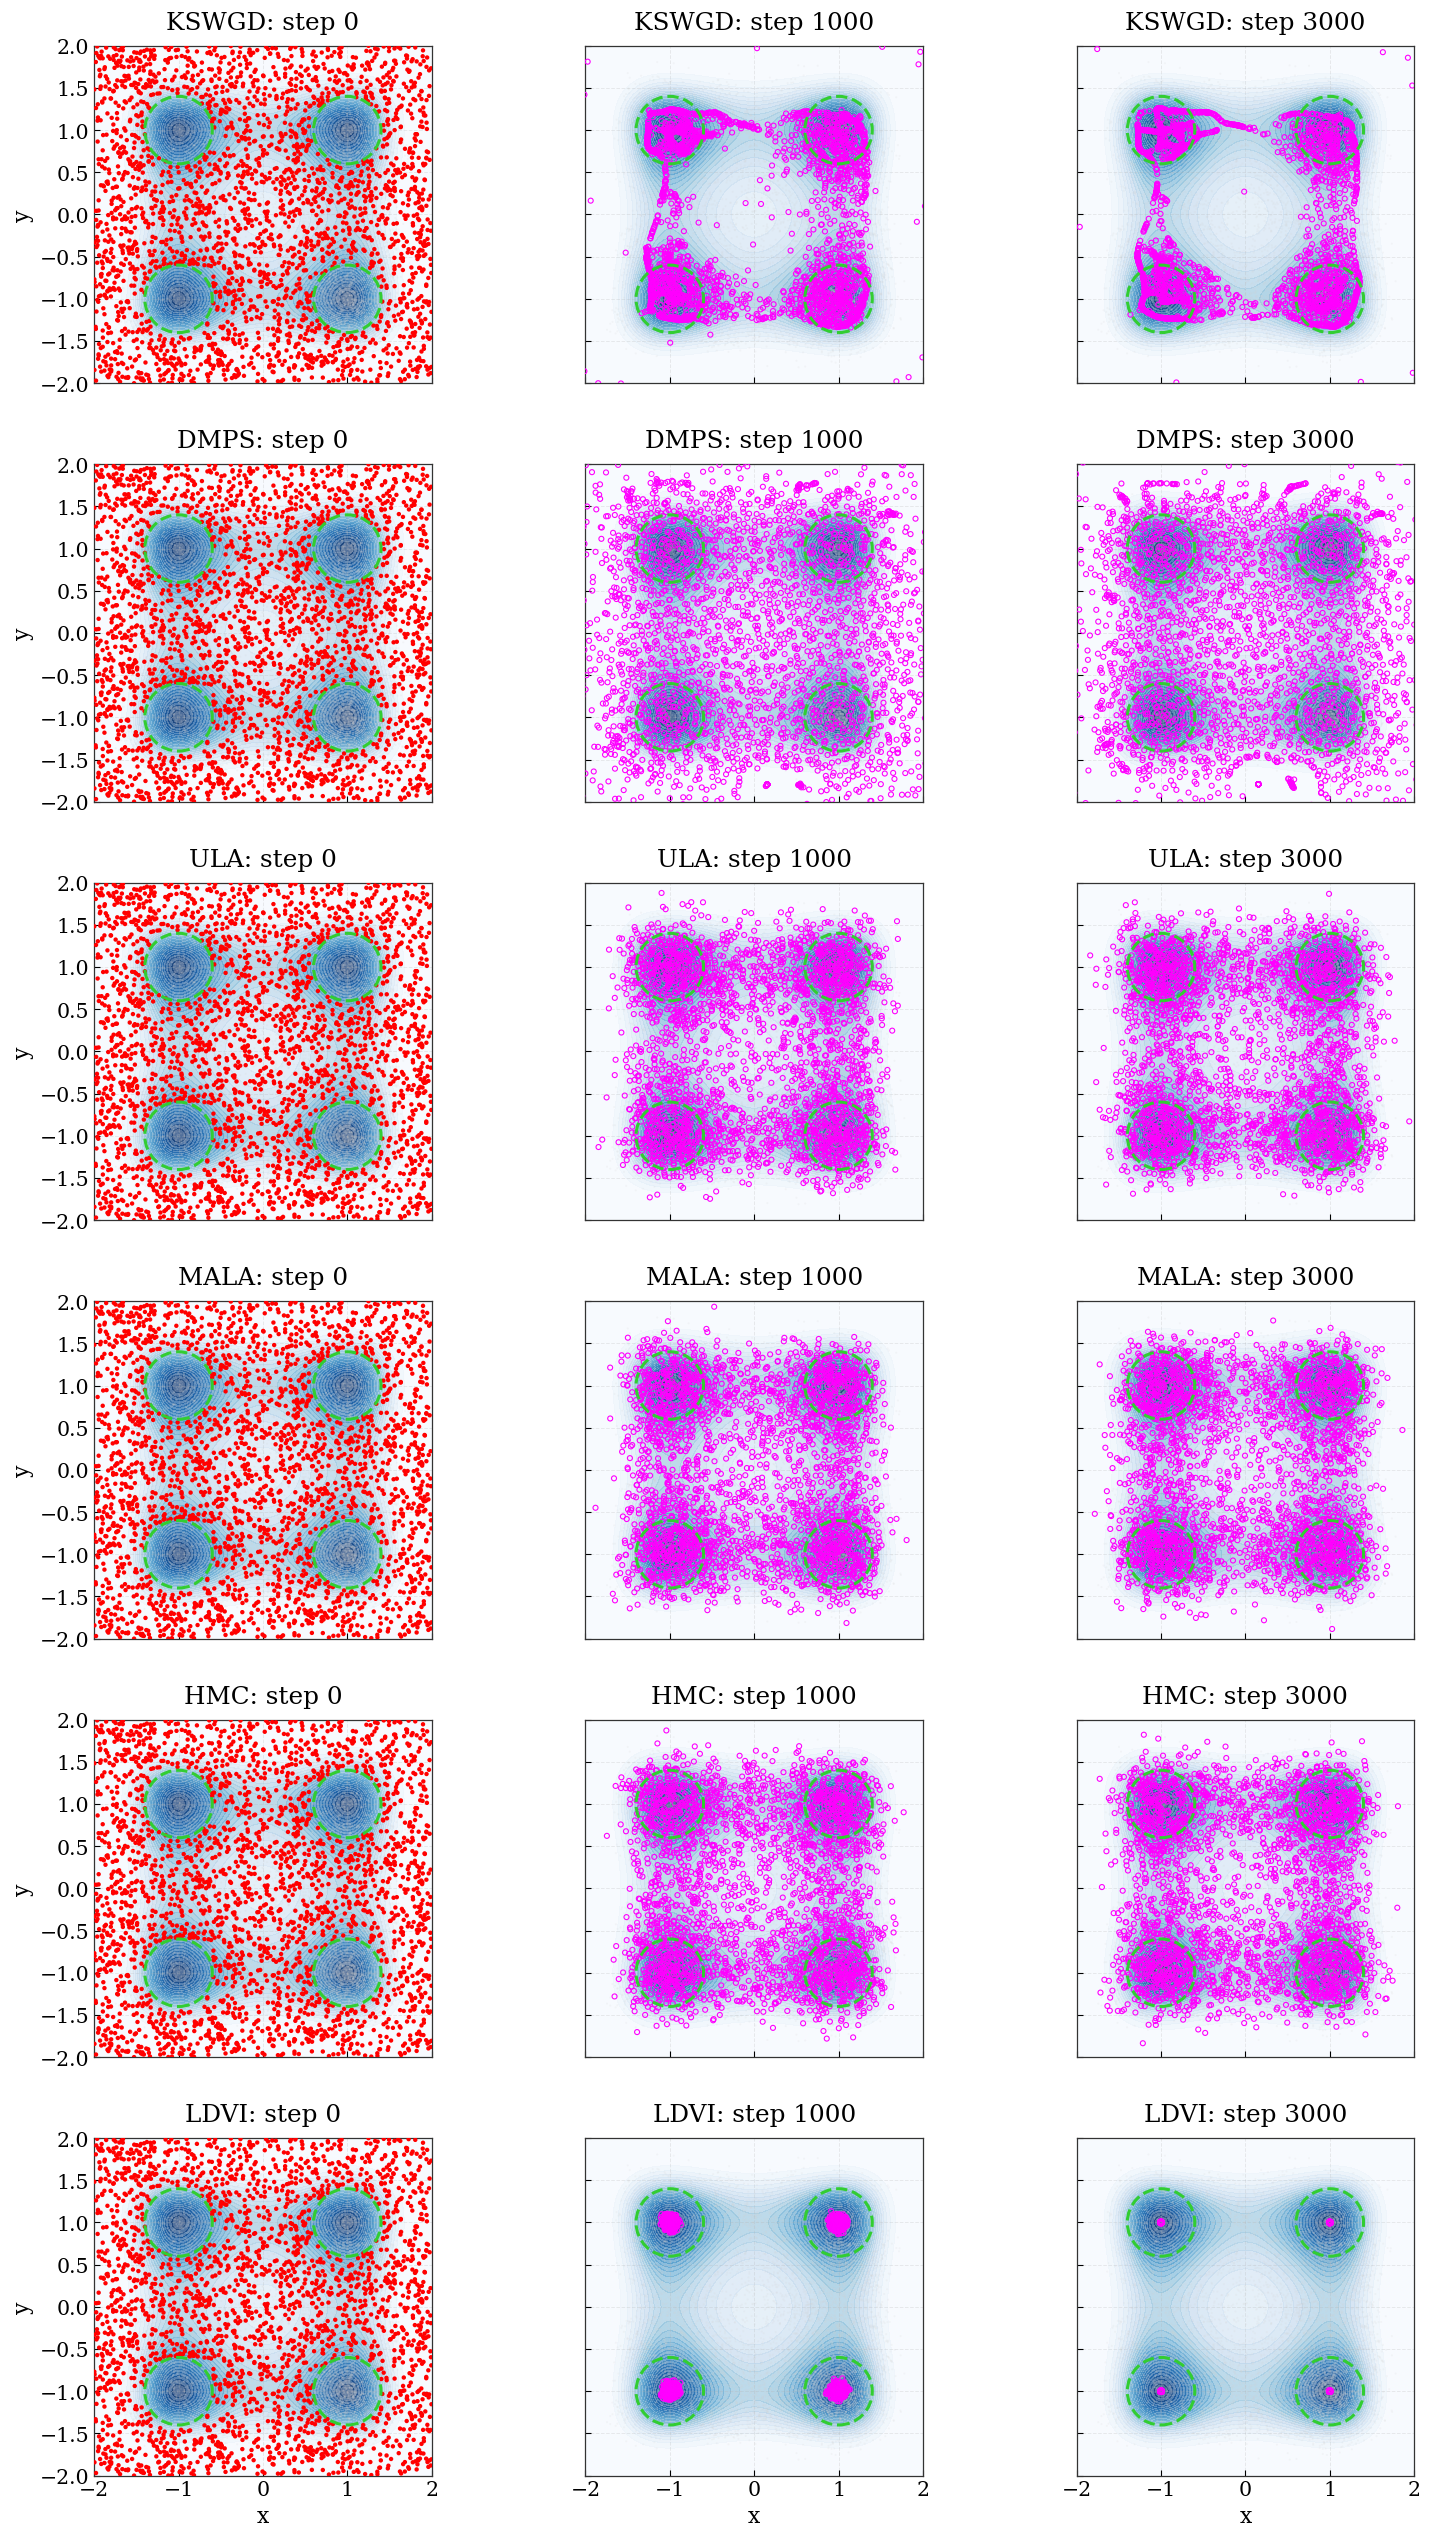

Caption: Quadruple-well particle snapshots for KSWGD, DMPS, and baseline samplers at initialization, 1000 iterations, and 3000 iterations.
Saved: figures/quadruple_well/test_2_quadruple_well_baseline_particle_snapshots.png and figures/quadruple_well/test_2_quadruple_well_baseline_particle_snapshots.pdf


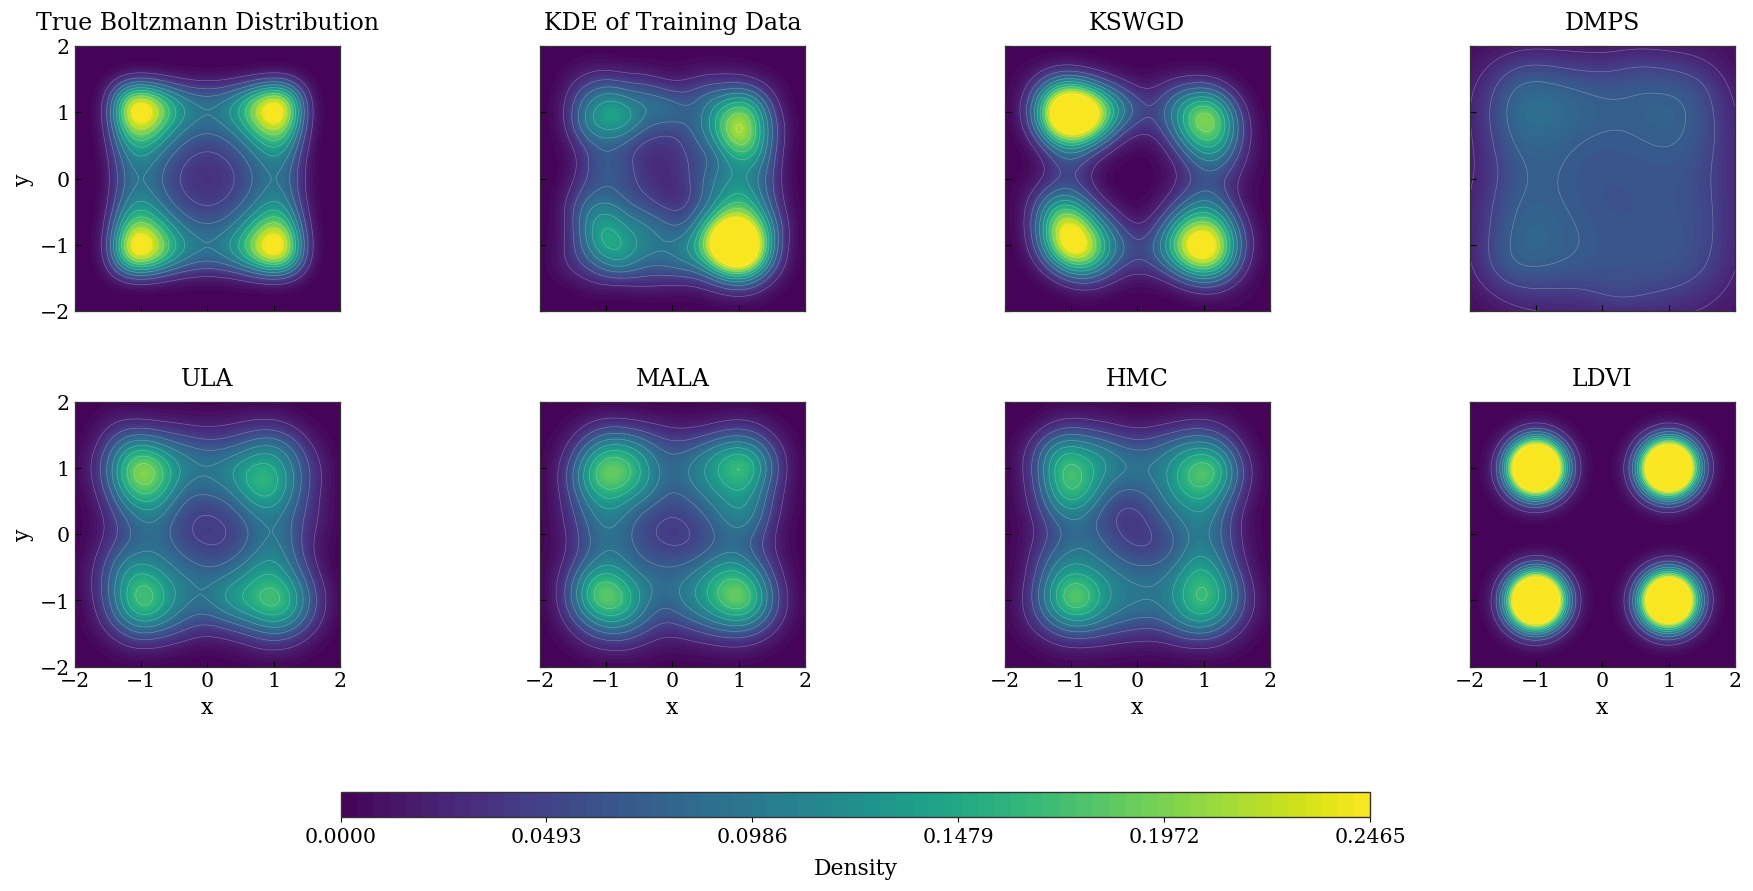

Caption: Final density heatmaps for the quadruple-well target, training data, KSWGD, DMPS, and baseline samplers.
Saved: figures/quadruple_well/test_2_quadruple_well_baseline_density_heatmaps.png and figures/quadruple_well/test_2_quadruple_well_baseline_density_heatmaps.pdf


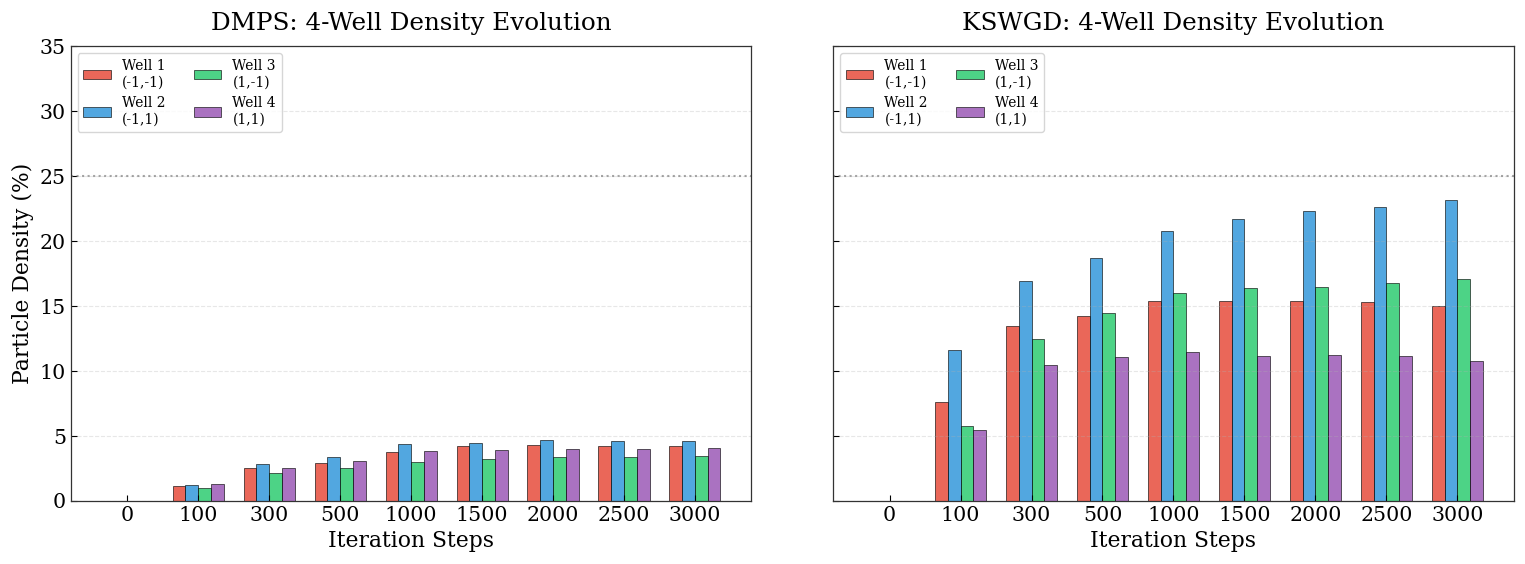

Caption: Four-well particle-density evolution for DMPS and KSWGD under the shared baseline-comparison setup.
Saved: figures/quadruple_well/test_2_quadruple_well_baseline_well_density_evolution.png and figures/quadruple_well/test_2_quadruple_well_baseline_well_density_evolution.pdf


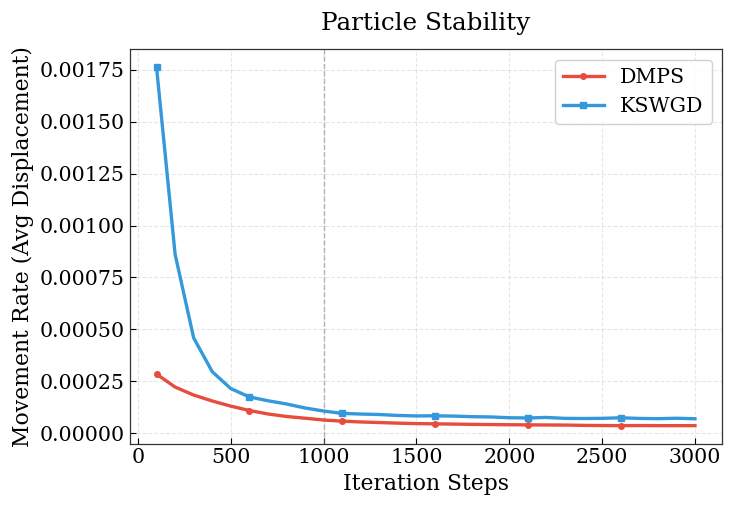

Caption: Mean particle displacement per recorded step for DMPS and KSWGD in the baseline-comparison setup.
Saved: figures/quadruple_well/test_2_quadruple_well_baseline_movement_rate.png and figures/quadruple_well/test_2_quadruple_well_baseline_movement_rate.pdf
Computing KL divergence curves for DMPS and KSWGD...


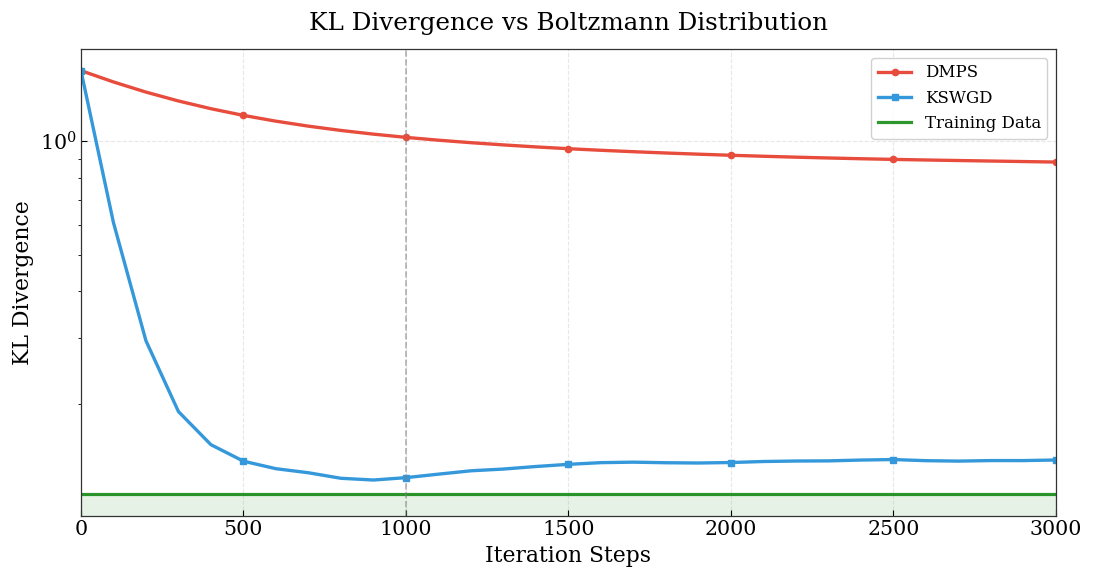

Caption: KL divergence from the true quadruple-well Boltzmann distribution for DMPS and KSWGD in the baseline-comparison setup.
Saved: figures/quadruple_well/test_2_quadruple_well_baseline_kl_divergence.png and figures/quadruple_well/test_2_quadruple_well_baseline_kl_divergence.pdf


In [3]:
snapshot_view = {name: {step: res.snapshots[step] for step in SNAPSHOT_STEPS} for name, res in method_results.items()}
plot_quad_pair_snapshots(
    snapshot_view, X_target=X_tar, potential=potential, bounds=cfg.bounds,
    centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_baseline_particle_snapshots',
    caption='Quadruple-well particle snapshots for KSWGD, DMPS, and baseline samplers at initialization, 1000 iterations, and 3000 iterations.',
)
plot_quad_heatmaps(
    {'True Boltzmann Distribution': 'boltzmann', 'KDE of Training Data': X_tar, **finals},
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_baseline_density_heatmaps',
    vmax_source='True Boltzmann Distribution',
    caption='Final density heatmaps for the quadruple-well target, training data, KSWGD, DMPS, and baseline samplers.',
)
well_density_view = {
    'DMPS': {step: dmps.snapshots[step] for step in WELL_DENSITY_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in WELL_DENSITY_STEPS},
}
plot_quad_well_density_evolution(
    well_density_view, centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_baseline_well_density_evolution',
    caption='Four-well particle-density evolution for DMPS and KSWGD under the shared baseline-comparison setup.',
)
plot_quad_movement_rate(
    {'DMPS': dmps.metrics, 'KSWGD': kswgd.metrics},
    stem='figures/quadruple_well/test_2_quadruple_well_baseline_movement_rate',
    caption='Mean particle displacement per recorded step for DMPS and KSWGD in the baseline-comparison setup.',
)
print('Computing KL divergence curves for DMPS and KSWGD...')
training_kl = compute_kl_divergence_kde(X_tar, potential)
kl_by_method = {
    name: np.asarray([compute_kl_divergence_kde(res.snapshots[step], potential) for step in KL_STEPS])
    for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items()
}
plot_quad_kl_divergence(
    kl_by_method, KL_STEPS, training_kl=training_kl,
    stem='figures/quadruple_well/test_2_quadruple_well_baseline_kl_divergence',
    caption='KL divergence from the true quadruple-well Boltzmann distribution for DMPS and KSWGD in the baseline-comparison setup.',
)